# HEAPO: Usage Examples
This notebook provides examples on how to use the dataset and related dataloader.

### Imports
**Note:** Before running the script, ensure that `data_path` is set to the correct location of the stored data.

In [111]:
# ----------------------
# IMPORT OTHER PACKAGES 
# ----------------------
import os 
import sys
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
from dateutil.relativedelta import relativedelta
import matplotlib.pyplot as plt

import seaborn as sns
import matplotlib.dates as mdates
plt.rcParams["font.family"] = "sans-serif"

# ----------------------
# IMPORT HEAPO SCRIPTS
# ----------------------

# either run script heapo.py inside the src folder
# folder_path = os.path.dirname(os.getcwd())+'/src/'
# %run -i {folder_path + 'heapo.py'}

# or import heapo as a package - RECOMMENDED because Visual Studio Code then recognizes the package
folder_path = os.path.dirname(os.path.dirname(os.getcwd()))
sys.path.insert(0,'/Users/svetlana/Documents/CAS_ML/Project/heapo-main/src')
from heapo import *

# ---------------------------------------
# DEFINE PATH TO WHERE THE DATA IS STORED
# ---------------------------------------

# NOTE: if data is stored under /data/ within this repository --> set data_path = None 
data_path = '/Users/svetlana/Documents/CAS_ML/Project/heapo_data/'

# otherwise please provide the absolute path to the HEAPO dataset including the last slash
# data_path = '/Users/user/path/to/heapo_data/'

# ---------------------------------------
# CREATE HEAPO OBJECT
# ---------------------------------------

# create HEAPO object
heapo = HEAPO(data_path=data_path, use_local_time=False, suppress_warning=False)

### Example: Print Statistics

In [112]:
# # ---------------------------------------
# print('*'*80+'\nGeneral Overview - Households Overview\n'+'*'*80)
# df_meta = heapo.get_meta_data_overview()
# print('Households - Total: {}'.format(len(df_meta)))
# print('Household - Treatment: {}'.format(len(df_meta[df_meta['Group'] == 'treatment'])))
# print('Households - Treatment [Double Visits]: {}'.format(len(df_meta[df_meta['Protocols_HasMultipleVisits']])))
# print('Household - Control: {}'.format(len(df_meta[df_meta['Group'] == 'control'])))
# print('Weather Stations: {}'.format(len(df_meta['Weather_ID'].unique())))
# print('Number of protocols: {}'.format(len(heapo.get_all_protocols())))

# # ---------------------------------------
# print('\n'+'*'*80+'\nGeneral Overview - Smart Meter Data\n'+'*'*80)
# df_overview = heapo.get_smart_meter_data_overview()
# print('Measurement Period - 15min: {} to {}'.format(df_overview['SMD_15min_TimeAvailable_EarliestTimestamp'].min().date(), df_overview['SMD_15min_TimeAvailable_LatestTimestamp'].max().date()))
# print('Measurement Period - daily: {} to {}'.format(df_overview['SMD_daily_TimeAvailable_EarliestTimestamp'].min().date(), df_overview['SMD_daily_TimeAvailable_LatestTimestamp'].max().date()))

# # ---------------------------------------
# df_treatment = df_overview.copy()
# df_treatment = df_treatment[df_treatment['Household_ID'].isin(heapo.get_all_households_with_protocols())]
# cols = ['Household_ID', 
#  'SMD_15min_TimeAvailable_NumberDays', 
#  'SMD_15min_TimeAvailable_DaysBeforeVisit', 
#  'SMD_15min_TimeAvailable_DaysAfterVisit', 
#  'SMD_daily_TimeAvailable_NumberDays', 
#  'SMD_daily_TimeAvailable_DaysBeforeVisit', 
#  'SMD_daily_TimeAvailable_DaysAfterVisit']
# df_treatment = df_treatment[cols]
# print('\n'+'*'*80)
# print('Treatment Group Overview - 15min Smart Meter Data\n'+'*'*80)
# print('Number of treatment household with before and after data: {}'.format(len(df_treatment[(df_treatment['SMD_15min_TimeAvailable_DaysBeforeVisit'] > 0) & (df_treatment['SMD_15min_TimeAvailable_DaysAfterVisit'] > 0)])))
# print('Number of treatment households with before and without after data: {}'.format(len(df_treatment[(df_treatment['SMD_15min_TimeAvailable_DaysBeforeVisit'] > 0) & ((df_treatment['SMD_15min_TimeAvailable_DaysAfterVisit'] == 0) | (df_treatment['SMD_15min_TimeAvailable_DaysAfterVisit'].isna()))])))
# print('Number of treatment households without before and with after data: {}'.format(len(df_treatment[((df_treatment['SMD_15min_TimeAvailable_DaysBeforeVisit'] == 0) | (df_treatment['SMD_15min_TimeAvailable_DaysBeforeVisit'].isna())) & (df_treatment['SMD_15min_TimeAvailable_DaysAfterVisit'] > 0)])))

# print('\n'+'*'*80)
# print('Treatment Group Overview - Daily Smart Meter Data\n'+'*'*80)
# print('Number of treatment household with before and after data: {}'.format(len(df_treatment[(df_treatment['SMD_daily_TimeAvailable_DaysBeforeVisit'] > 0) & (df_treatment['SMD_daily_TimeAvailable_DaysAfterVisit'] > 0)])))
# print('Number of treatment households with before and without after data: {}'.format(len(df_treatment[(df_treatment['SMD_daily_TimeAvailable_DaysBeforeVisit'] > 0) & ((df_treatment['SMD_daily_TimeAvailable_DaysAfterVisit'] == 0) | (df_treatment['SMD_daily_TimeAvailable_DaysAfterVisit'].isna()))])))
# print('Number of treatment households without before and with after data: {}'.format(len(df_treatment[((df_treatment['SMD_daily_TimeAvailable_DaysBeforeVisit'] == 0) | (df_treatment['SMD_daily_TimeAvailable_DaysBeforeVisit'].isna())) & (df_treatment['SMD_daily_TimeAvailable_DaysAfterVisit'] > 0)])))

# # ---------------------------------------
# #display(df_overview)
# #display(df_meta)
# #display(df_treatment)
# #df_meta.columns


### Example: Load Data

In [113]:
# # --------------------------------
# # EXAMPLE: LOAD DATA
# # --------------------------------

# # select household ID 
# household_id = 7710511

# # load data individually 
# df_smd = heapo.load_smart_meter_data(household_id, resolution='15min')
# df_weather = heapo.load_weather_data(household_id, resolution='hourly_and_daily')
# df_protocol = heapo.load_protocol_data(household_id)

# # load smart meter data of multiple households at once 
# df_multiple = heapo.load_smart_meter_data_multiple([7710511, 105807], resolution='15min')

# # load combined weather and smart meter data and add temporal context 
# df = heapo.load_smart_meter_and_weather_data_combined(household_id, smd_resolution='15min', weather_resolution='hourly_and_daily', interpolate_hourly=True)
# df = heapo.add_temporal_information(df, inplace=True)

# # limit time series around report date 
# report_date = df_protocol['Visit_Date'].iloc[0]
# df = heapo.limit_time_series_around_date(df, report_date, months_before=1, months_after=1, inplace=True)

# # split into before and after report date
# df_before, df_during, df_after = heapo.split_time_series_around_consultation(df)

# # --------------------------------
# # EXAMPLE: PLOT ENERGY CONSUMPTION
# # --------------------------------

# fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)
# fig.suptitle('Household: {}'.format(household_id), fontweight='bold')

# # plot temperature 
# ax = axes[0]
# ax.plot(df['Timestamp'].values, df['Temperature_avg_hourly'].values, color=COLOR_DARK)
# ax.set_ylabel('Outdoor Temperature [°C]')
# ax.grid(alpha=0.3)

# # plot energy consumption
# ax = axes[1]
# if len(df_before) > 0:
#     ax.plot(df_before['Timestamp'].values, df_before['kWh_received_Total'].values, color=COLOR_PURPLE, label='Before Consultation')
# if len(df_during) > 0:
#     ax.plot(df_during['Timestamp'].values, df_during['kWh_received_Total'].values, color=COLOR_RED, label='During Consultation')
# if len(df_after) > 0:
#     ax.plot(df_after['Timestamp'].values, df_after['kWh_received_Total'].values, color=COLOR_YELLOW, label='After Consultation')
# ax.set_xlabel('Time')
# ax.set_ylabel('Total Energy Consumption [kWh]')
# ax.set_xlim(df_before['Timestamp'].min(), df_after['Timestamp'].max())
# ax.set_ylim(0, df['kWh_received_Total'].max() * 1.1)
# ax.legend()
# ax.grid(alpha=0.3)

# fig.tight_layout()
# plt.show()

# display(df)

## Problem Definition
**Task**: Predict monthly electricity consumption per household

**Input features**:
Living area (m2)
Number of residents
Heat pump type
Appliances:
EV (yes/no)
Dryer
Freezer

**Target**:
Monthly electricity consumption (kWh)

### Dataset Preparation

I need to aggregate the time-series into monthly values

In [114]:
# household_id = 7710511
# df_meta = heapo.load_smart_meter_data_multiple(household_id, resolution='monthly')
# df_meta

In [115]:
# # convert timestamp to datetime
# df_meta['Timestamp'] = pd.to_datetime(df_meta['Timestamp'])

# # create month column
# df_meta['month'] = df_meta['Timestamp'].dt.to_period('M')

# # separate year and month
# #df['year'] = df['Timestamp'].dt.year
# #df['month'] = df['Timestamp'].dt.month

# # aggregate to monthly consumption
# df_monthly = (
#     df_meta.groupby(['Household_ID', 'month'])['kWh_received_Total']
#     .sum()
#     .reset_index()
# )
# df_monthly = df_monthly[['Household_ID', 'month','kWh_received_Total']]
# df_monthly['month'] = df_monthly['month'].dt.to_timestamp()
# df_monthly.head()

# # plot consumption for ONE household
# plt.figure()
# plt.plot(df_monthly['month'], df_monthly['kWh_received_Total'])
# plt.xlabel('Month')
# plt.ylabel('Energy Consumption (kWh)')
# plt.title(f'Household {household_id} - Monthly Consumption')
# plt.xticks(rotation=45)
# plt.tight_layout()
# plt.show()


In [116]:
df_meta_1 = heapo.get_meta_data_overview()
df_meta_1.count()

Household_ID                                   1408
Group                                          1408
Weather_ID                                     1408
Installation_HasPVSystem                        650
Protocols_Available                            1408
Protocols_HasMultipleVisits                    1408
Protocols_ReportIDs                             214
MetaData_Available                             1408
SmartMeterData_Available_15min                 1408
SmartMeterData_Available_Daily                 1408
SmartMeterData_Available_Monthly               1408
Survey_Building_Type                           1356
Survey_Building_LivingArea                     1339
Survey_Building_Residents                      1348
Survey_HeatPump_Installation_Type              1354
Survey_HeatDistribution_System_FloorHeating    1310
Survey_HeatDistribution_System_Radiator        1310
Survey_DHW_Production_ByHeatPump                851
Survey_DHW_Production_ByElectricWaterHeater     424
Survey_DHW_P

In [117]:
df_meta_1.groupby('Survey_Building_Type').count()

,Household_ID,Group,Weather_ID,Installation_HasPVSystem,Protocols_Available,Protocols_HasMultipleVisits,Protocols_ReportIDs,MetaData_Available,SmartMeterData_Available_15min,SmartMeterData_Available_Daily,...,Survey_Building_Residents,Survey_HeatPump_Installation_Type,Survey_HeatDistribution_System_FloorHeating,Survey_HeatDistribution_System_Radiator,Survey_DHW_Production_ByHeatPump,Survey_DHW_Production_ByElectricWaterHeater,Survey_DHW_Production_BySolar,Survey_Installation_HasDryer,Survey_Installation_HasFreezer,Survey_Installation_HasElectricVehicle
Survey_Building_Type,,,,,,,,,,,,,,,,,,,,,
appartment,9,9,9,5,9,9,2,9,9,9,...,9,9,7,7,7,1,1,8,8,6
house,1347,1347,1347,625,1347,1347,162,1347,1347,1347,...,1338,1344,1302,1302,843,423,69,1340,1340,1180


In [118]:
df_meta_col = df_meta_1[
    ['Household_ID',
     'Survey_Building_Residents',
     'Survey_Building_LivingArea',
     'Survey_HeatPump_Installation_Type',
     'Survey_HeatDistribution_System_FloorHeating',
     'Survey_HeatDistribution_System_Radiator',
     'Survey_Installation_HasElectricVehicle',
     'Survey_Installation_HasFreezer',
     'Survey_Installation_HasDryer',
    ]
]
df_meta_col = df_meta_col.rename(columns=lambda x: x.replace('Survey_', ''))
df_meta_col.head()

,Household_ID,Building_Residents,Building_LivingArea,HeatPump_Installation_Type,HeatDistribution_System_FloorHeating,HeatDistribution_System_Radiator,Installation_HasElectricVehicle,Installation_HasFreezer,Installation_HasDryer
0,1060,2.0,180.0,air-source,True,False,False,True,True
1,10266,2.0,240.0,air-source,False,True,True,True,True
2,11769,1.0,200.0,air-source,True,False,False,True,True
3,24611,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,65651,2.0,180.0,air-source,False,True,False,True,False


In [119]:
def load_smart_meter_data_multiple_safe(household_ids):
    df_final = pd.DataFrame()
    for hid in household_ids:
        try:
            df = heapo.load_smart_meter_data(hid, resolution='monthly')
            if df is not None: 
                df_final = pd.concat([df_final, df], axis=0)
        except Exception as e:
            # print(f'{hid} error', e)
            pass
    df_final.drop_duplicates(inplace=True)
    df_final.reset_index(drop=True, inplace=True)
    if heapo.use_local_time: 
        df_final = heapo.__convert_UTC_to_local_time__(df_final, inplace=True)
    return df_final

houshold_ids = df_meta_col['Household_ID'].tolist()
#houshold_ids

In [120]:
df_meta = load_smart_meter_data_multiple_safe(houshold_ids)
df_meta

,Household_ID,Group,AffectsTimePoint,Timestamp,kWh_received_Total,kWh_received_HeatPump,kWh_received_Other,kWh_returned_Total,kvarh_received_capacitive_Total,kvarh_received_capacitive_HeatPump,kvarh_received_capacitive_Other,kvarh_received_inductive_Total,kvarh_received_inductive_HeatPump,kvarh_received_inductive_Other
0,1060,control,unknown,2022-05-31 23:59:59+00:00,653.90,NaN,NaN,NaN,17.81,NaN,NaN,8.25,NaN,NaN
1,1060,control,unknown,2022-06-30 23:59:59+00:00,486.23,NaN,NaN,NaN,9.39,NaN,NaN,12.55,NaN,NaN
2,1060,control,unknown,2022-07-31 23:59:59+00:00,494.41,NaN,NaN,NaN,12.63,NaN,NaN,3.92,NaN,NaN
3,1060,control,unknown,2022-08-31 23:59:59+00:00,476.31,NaN,NaN,NaN,13.04,NaN,NaN,3.30,NaN,NaN
4,1060,control,unknown,2022-09-30 23:59:59+00:00,550.09,NaN,NaN,NaN,115.77,NaN,NaN,0.51,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
30205,9981041,treatment,after visit,2023-10-31 23:59:59+00:00,844.16,NaN,NaN,202.01,326.88,NaN,NaN,331.81,NaN,NaN
30206,9981041,treatment,after visit,2023-11-30 23:59:59+00:00,1236.10,NaN,NaN,53.27,266.34,NaN,NaN,658.23,NaN,NaN
30207,9981041,treatment,after visit,2023-12-31 23:59:59+00:00,1488.75,NaN,NaN,28.81,245.99,NaN,NaN,804.22,NaN,NaN
30208,9981041,treatment,after visit,2024-01-31 23:59:59+00:00,1653.95,NaN,NaN,42.73,223.19,NaN,NaN,887.61,NaN,NaN


In [121]:
df_meta['Household_ID'].unique().shape

(1264,)

In [122]:
def weather_per_month_for_household(household_id):
    weather = heapo.load_weather_data(household_id, resolution='daily')
    weather["Timestamp"] = pd.to_datetime(weather["Timestamp"])
    
    weather["month"] = weather["Timestamp"].dt.month
    
    monthly_stats = (
        weather.groupby("month")["Temperature_avg_daily"]
          .agg(["mean"])
    )
    monthly_stats = monthly_stats.rename(columns={
        "mean": "monthly_avg_temp",
    })
    monthly_stats['Household_ID'] = household_id
    monthly_stats.reset_index(inplace=True)
    return monthly_stats

def load_weather_data_safe(household_ids):
    df_final = pd.DataFrame()
    for hid in household_ids:
        try:
            df = weather_per_month_for_household(hid)
            if df is not None: 
                df_final = pd.concat([df_final, df], axis=0)
        except Exception as e:
            print(f'{hid} error', e)
            #pass
    df_final.drop_duplicates(inplace=True)
    df_final.reset_index(drop=True, inplace=True)
    return df_final


df_weather = load_weather_data_safe(df_meta['Household_ID'].unique())
df_weather

,month,monthly_avg_temp,Household_ID
0,1,1.752151,1060
1,2,4.613609,1060
2,3,6.396129,1060
3,4,9.535333,1060
4,5,13.336774,1060
...,...,...,...
15163,8,19.467097,9981041
15164,9,16.220000,9981041
15165,10,11.617419,9981041
15166,11,6.015333,9981041


In [123]:
df_meta_tmp = df_meta[['Household_ID', 'kWh_received_Total', 'Timestamp']]
df_meta_tmp["Timestamp"] = pd.to_datetime(df_meta_tmp["Timestamp"])
df_meta_tmp["month"] = df_meta_tmp["Timestamp"].dt.month

df_meta_2 = df_meta_tmp.groupby(['Household_ID', 'month'])['kWh_received_Total'].mean().reset_index()
df_meta_2

/var/folders/kh/qfjhgnwx6lj17jd04nqjhjl80000gp/T/ipykernel_7353/27001086.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_meta_tmp["Timestamp"] = pd.to_datetime(df_meta_tmp["Timestamp"])
/var/folders/kh/qfjhgnwx6lj17jd04nqjhjl80000gp/T/ipykernel_7353/27001086.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_meta_tmp["month"] = df_meta_tmp["Timestamp"].dt.month


,Household_ID,month,kWh_received_Total
0,1060,1,1184.615
1,1060,2,877.060
2,1060,3,2329.530
3,1060,4,1559.840
4,1060,5,563.665
...,...,...,...
13753,9981041,8,453.810
13754,9981041,9,453.860
13755,9981041,10,844.160
13756,9981041,11,1236.100


In [124]:
# merge with Household Metadata
merge1_df = df_meta_2.merge(df_meta_col, on = 'Household_ID', how = 'left')
final_df = merge1_df.merge(df_weather, on = ['Household_ID', 'month'], how = 'left')
final_df.info()
final_df.head(10)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13758 entries, 0 to 13757
Data columns (total 12 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   Household_ID                          13758 non-null  int64  
 1   month                                 13758 non-null  int32  
 2   kWh_received_Total                    13559 non-null  float64
 3   Building_Residents                    13528 non-null  float64
 4   Building_LivingArea                   13461 non-null  float64
 5   HeatPump_Installation_Type            13590 non-null  object 
 6   HeatDistribution_System_FloorHeating  13240 non-null  object 
 7   HeatDistribution_System_Radiator      13240 non-null  object 
 8   Installation_HasElectricVehicle       12124 non-null  object 
 9   Installation_HasFreezer               13538 non-null  object 
 10  Installation_HasDryer                 13538 non-null  object 
 11  monthly_avg_tem

,Household_ID,month,kWh_received_Total,Building_Residents,Building_LivingArea,HeatPump_Installation_Type,HeatDistribution_System_FloorHeating,HeatDistribution_System_Radiator,Installation_HasElectricVehicle,Installation_HasFreezer,Installation_HasDryer,monthly_avg_temp
0,1060,1,1184.615,2.0,180.0,air-source,True,False,False,True,True,1.752151
1,1060,2,877.060,2.0,180.0,air-source,True,False,False,True,True,4.613609
2,1060,3,2329.530,2.0,180.0,air-source,True,False,False,True,True,6.396129
3,1060,4,1559.840,2.0,180.0,air-source,True,False,False,True,True,9.535333
4,1060,5,563.665,2.0,180.0,air-source,True,False,False,True,True,13.336774
5,1060,6,404.425,2.0,180.0,air-source,True,False,False,True,True,19.032667
6,1060,7,427.720,2.0,180.0,air-source,True,False,False,True,True,20.214839
7,1060,8,430.370,2.0,180.0,air-source,True,False,False,True,True,19.405806
8,1060,9,436.560,2.0,180.0,air-source,True,False,False,True,True,15.881333
9,1060,10,556.405,2.0,180.0,air-source,True,False,False,True,True,11.210968


In [125]:
# missing values
final_df.isnull().sum()

Household_ID                               0
month                                      0
kWh_received_Total                       199
Building_Residents                       230
Building_LivingArea                      297
HeatPump_Installation_Type               168
HeatDistribution_System_FloorHeating     518
HeatDistribution_System_Radiator         518
Installation_HasElectricVehicle         1634
Installation_HasFreezer                  220
Installation_HasDryer                    220
monthly_avg_temp                           0
dtype: int64

In [126]:
final_df['kWh_received_Total'].describe()

count    13559.000000
mean       835.595001
std        615.275680
min          3.335000
25%        412.673333
50%        700.504000
75%       1114.582500
max      11049.753333
Name: kWh_received_Total, dtype: float64

In [127]:
df = final_df.dropna(subset=['kWh_received_Total'])
df.isnull().sum()

Household_ID                               0
month                                      0
kWh_received_Total                         0
Building_Residents                       219
Building_LivingArea                      286
HeatPump_Installation_Type               157
HeatDistribution_System_FloorHeating     505
HeatDistribution_System_Radiator         505
Installation_HasElectricVehicle         1587
Installation_HasFreezer                  209
Installation_HasDryer                    209
monthly_avg_temp                           0
dtype: int64

In [128]:
df

,Household_ID,month,kWh_received_Total,Building_Residents,Building_LivingArea,HeatPump_Installation_Type,HeatDistribution_System_FloorHeating,HeatDistribution_System_Radiator,Installation_HasElectricVehicle,Installation_HasFreezer,Installation_HasDryer,monthly_avg_temp
0,1060,1,1184.615,2.0,180.0,air-source,True,False,False,True,True,1.752151
1,1060,2,877.060,2.0,180.0,air-source,True,False,False,True,True,4.613609
2,1060,3,2329.530,2.0,180.0,air-source,True,False,False,True,True,6.396129
3,1060,4,1559.840,2.0,180.0,air-source,True,False,False,True,True,9.535333
4,1060,5,563.665,2.0,180.0,air-source,True,False,False,True,True,13.336774
...,...,...,...,...,...,...,...,...,...,...,...,...
13753,9981041,8,453.810,3.0,360.0,ground-source,True,False,NaN,True,False,19.467097
13754,9981041,9,453.860,3.0,360.0,ground-source,True,False,NaN,True,False,16.220000
13755,9981041,10,844.160,3.0,360.0,ground-source,True,False,NaN,True,False,11.617419
13756,9981041,11,1236.100,3.0,360.0,ground-source,True,False,NaN,True,False,6.015333


In [129]:
df = df.dropna()
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 11528 entries, 0 to 13745
Data columns (total 12 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   Household_ID                          11528 non-null  int64  
 1   month                                 11528 non-null  int32  
 2   kWh_received_Total                    11528 non-null  float64
 3   Building_Residents                    11528 non-null  float64
 4   Building_LivingArea                   11528 non-null  float64
 5   HeatPump_Installation_Type            11528 non-null  object 
 6   HeatDistribution_System_FloorHeating  11528 non-null  object 
 7   HeatDistribution_System_Radiator      11528 non-null  object 
 8   Installation_HasElectricVehicle       11528 non-null  object 
 9   Installation_HasFreezer               11528 non-null  object 
 10  Installation_HasDryer                 11528 non-null  object 
 11  monthly_avg_temp    

In [130]:
df.isna().sum()

Household_ID                            0
month                                   0
kWh_received_Total                      0
Building_Residents                      0
Building_LivingArea                     0
HeatPump_Installation_Type              0
HeatDistribution_System_FloorHeating    0
HeatDistribution_System_Radiator        0
Installation_HasElectricVehicle         0
Installation_HasFreezer                 0
Installation_HasDryer                   0
monthly_avg_temp                        0
dtype: int64

In [131]:
df['HeatPump_Installation_Type'].value_counts()

HeatPump_Installation_Type
air-source       6421
ground-source    5107
Name: count, dtype: int64

In [132]:
df['HeatPump_Installation_Type'] = df['HeatPump_Installation_Type'].map({
    'air-source': 0,
    'ground-source': 1
})


/var/folders/kh/qfjhgnwx6lj17jd04nqjhjl80000gp/T/ipykernel_7353/1714013267.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['HeatPump_Installation_Type'] = df['HeatPump_Installation_Type'].map({


In [133]:
bool_cols = ['HeatDistribution_System_FloorHeating',
             'HeatDistribution_System_Radiator',
     'Installation_HasElectricVehicle',
     'Installation_HasFreezer',
     'Installation_HasDryer',
            ]
for col in bool_cols:
    df[col] = df[col].astype(float)


/var/folders/kh/qfjhgnwx6lj17jd04nqjhjl80000gp/T/ipykernel_7353/1710194026.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[col] = df[col].astype(float)
/var/folders/kh/qfjhgnwx6lj17jd04nqjhjl80000gp/T/ipykernel_7353/1710194026.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[col] = df[col].astype(float)
/var/folders/kh/qfjhgnwx6lj17jd04nqjhjl80000gp/T/ipykernel_7353/1710194026.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_in

In [134]:
df.drop(columns=['month'], inplace=True)

/var/folders/kh/qfjhgnwx6lj17jd04nqjhjl80000gp/T/ipykernel_7353/1558433883.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.drop(columns=['month'], inplace=True)


In [187]:
#df = df[df['kWh_received_Total'] < 6000]
#Handle outliers
df = df[df['kWh_received_Total'] < df['kWh_received_Total'].quantile(0.99)]
df

,Household_ID,kWh_received_Total,Building_Residents,Building_LivingArea,HeatPump_Installation_Type,HeatDistribution_System_FloorHeating,HeatDistribution_System_Radiator,Installation_HasElectricVehicle,Installation_HasFreezer,Installation_HasDryer,monthly_avg_temp
0,1060,1184.615,2.0,180.0,0,1.0,0.0,0.0,1.0,1.0,1.752151
1,1060,877.060,2.0,180.0,0,1.0,0.0,0.0,1.0,1.0,4.613609
2,1060,2329.530,2.0,180.0,0,1.0,0.0,0.0,1.0,1.0,6.396129
3,1060,1559.840,2.0,180.0,0,1.0,0.0,0.0,1.0,1.0,9.535333
4,1060,563.665,2.0,180.0,0,1.0,0.0,0.0,1.0,1.0,13.336774
...,...,...,...,...,...,...,...,...,...,...,...
13741,9980121,404.290,2.0,165.0,0,1.0,0.0,0.0,0.0,1.0,19.405806
13742,9980121,289.045,2.0,165.0,0,1.0,0.0,0.0,0.0,1.0,15.881333
13743,9980121,350.580,2.0,165.0,0,1.0,0.0,0.0,0.0,1.0,11.210968
13744,9980121,486.015,2.0,165.0,0,1.0,0.0,0.0,0.0,1.0,5.577333


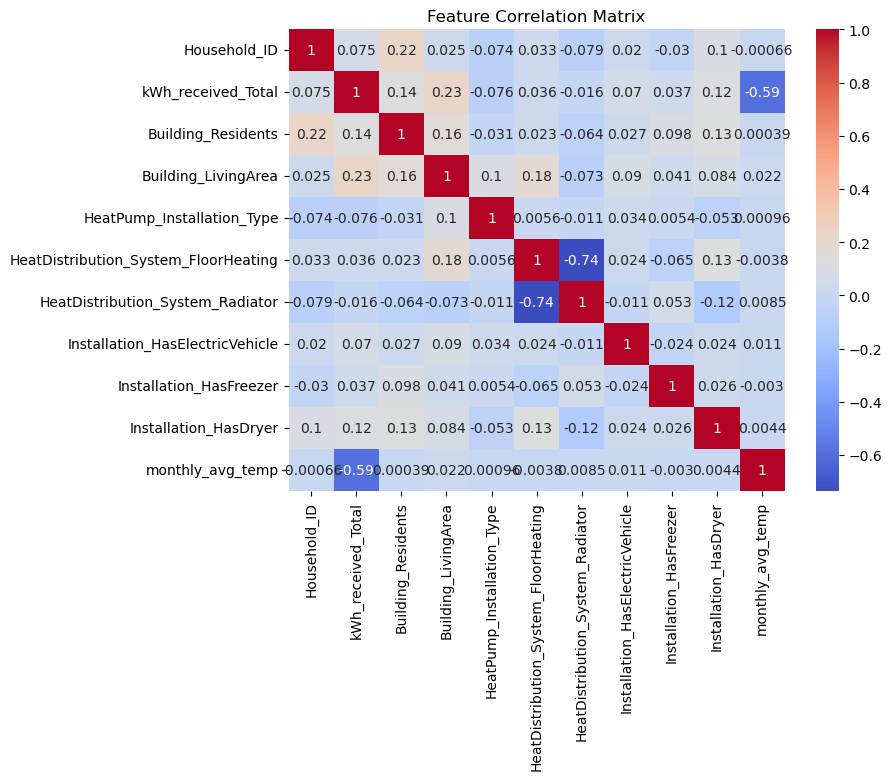

In [188]:
# correlation heatmap
import seaborn as sns

plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title('Feature Correlation Matrix')
plt.show()

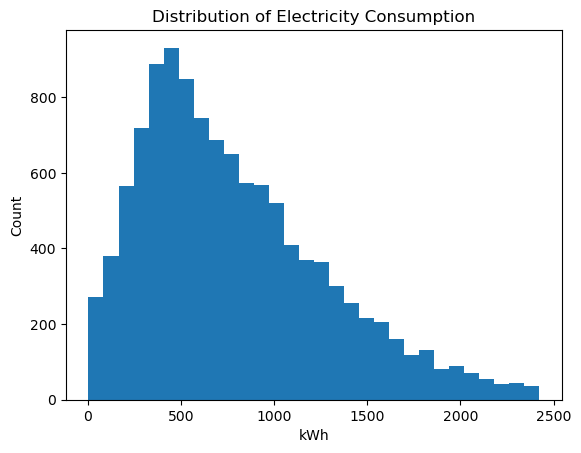

In [189]:
# How is electricity consumption distributed
plt.figure()
plt.hist(df['kWh_received_Total'], bins=30)
plt.xlabel('kWh')
plt.ylabel('Count')
plt.title('Distribution of Electricity Consumption')
plt.show()

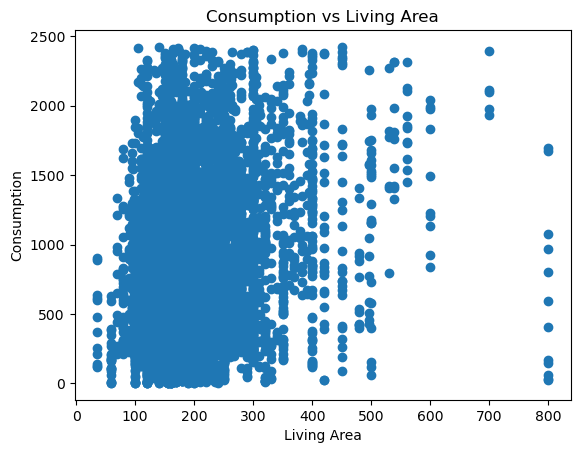

In [190]:
# Consumption vs Living Area
plt.figure()
plt.scatter(df['Building_LivingArea'], df['kWh_received_Total'])
plt.xlabel('Living Area')
plt.ylabel('Consumption')
plt.title('Consumption vs Living Area')
plt.show()

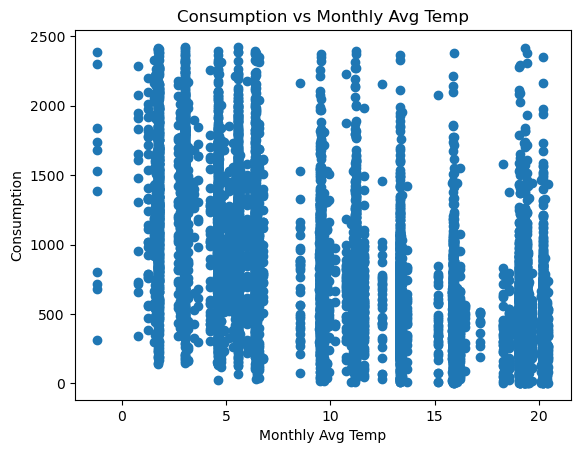

In [191]:
# Consumption vs Living Area
plt.figure()
plt.scatter(df['monthly_avg_temp'], df['kWh_received_Total'])
plt.xlabel('Monthly Avg Temp')
plt.ylabel('Consumption')
plt.title('Consumption vs Monthly Avg Temp')
plt.show()

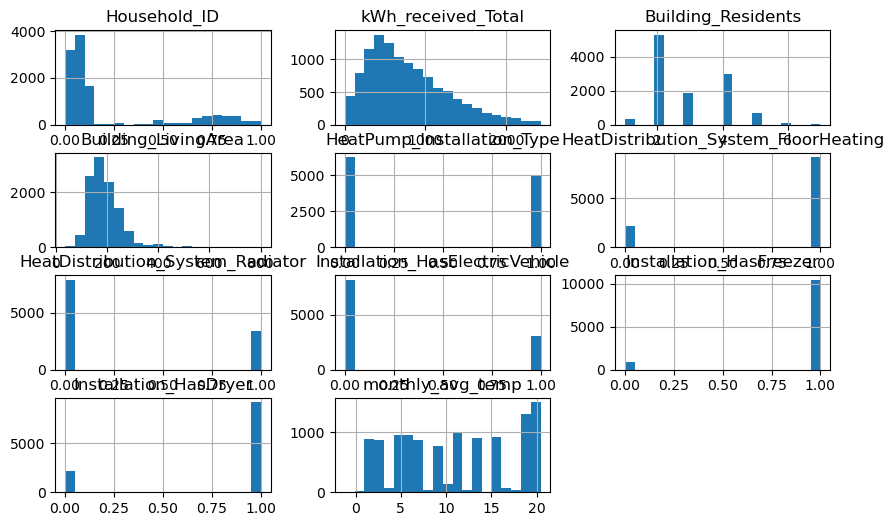

In [192]:
# Feature distributions
df.hist(figsize=(10, 6), bins=20)
plt.show()

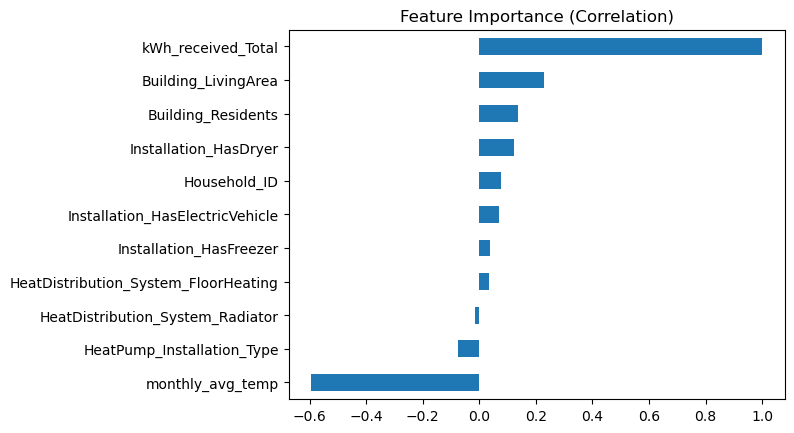

In [193]:
df.corr(numeric_only=True)['kWh_received_Total'].sort_values().plot(kind='barh')
plt.title('Feature Importance (Correlation)')
plt.show()


**Which features matter most**

**Living area** → strongest predictor
**Residents** → second
**Heating system** → smaller effect

## Regression
### Linear Regression

In [207]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


Linear Regression Results:
MAE: 271.88378795699725
RMSE: 363.56565627719147
R²: 0.4439331571036248
Linear Regression Results:
MAE: 306.20135229387625
RMSE: 396.61037708737376
R²: 0.43178755191395257


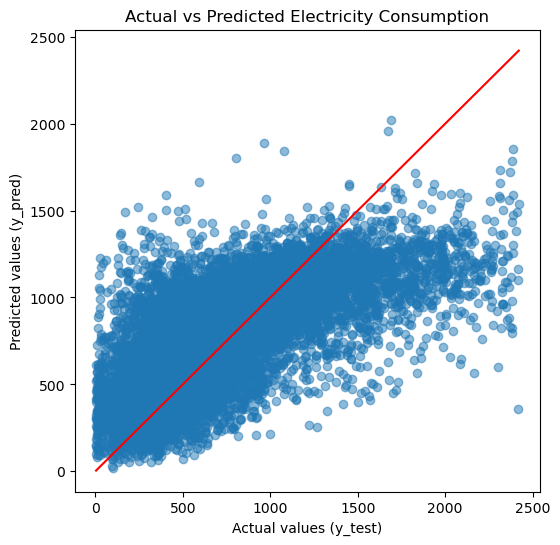

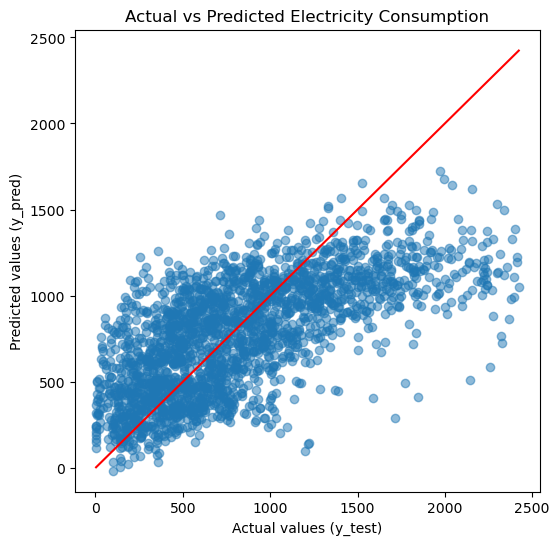

In [208]:
# 1. Define features (X) and target (y)
X = df.drop(columns = ['kWh_received_Total','Household_ID'])
y = df['kWh_received_Total']

# 2. Train-test split
# Split using Household_ID
households = df["Household_ID"].unique()

train_households, test_households = train_test_split(households, test_size=0.2, random_state=42)
train_df = df[df["Household_ID"].isin(train_households)]
test_df  = df[df["Household_ID"].isin(test_households)]

#Remove target AND ID from features
X_train = train_df.drop(columns=["kWh_received_Total", "Household_ID"])
y_train = train_df["kWh_received_Total"]

X_test = test_df.drop(columns=["kWh_received_Total", "Household_ID"])
y_test = test_df["kWh_received_Total"]

#Scale properly
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

#3. Create model
model = LinearRegression()

#4. Train model
model.fit(X_train, y_train)

def compute_metrics(model, X, Y):
    #5. Make predictions
    y_pred = model.predict(X)
    
    # 6. Evaluate model
    mae = mean_absolute_error(Y, y_pred)
    rmse = np.sqrt(mean_squared_error(Y, y_pred))
    r2 = r2_score(Y, y_pred)
    
    print("Linear Regression Results:")
    print("MAE:", mae)
    print("RMSE:", rmse)
    print("R²:", r2)

def plot_predictions(model, X, y):
    y_pred = model.predict(X)
    plt.figure(figsize=(6,6))
    plt.scatter(y, y_pred, alpha=0.5)
    
    plt.xlabel("Actual values (y_test)")
    plt.ylabel("Predicted values (y_pred)")
    plt.title("Actual vs Predicted Electricity Consumption")
    
    # diagonal reference line (perfect prediction)
    plt.plot([y.min(), y.max()],
             [y.min(), y.max()],
             color='red')
    
    plt.show()    

compute_metrics(model, X_train, y_train)
compute_metrics(model, X_test, y_test)
plot_predictions(model, X_train, y_train)
plot_predictions(model, X_test, y_test)

In [209]:
#train_df
#test_df

### Random Forest

Linear Regression Results:
MAE: 260.07625251654565
RMSE: 346.0489561808665
R²: 0.4962252641170579
Linear Regression Results:
MAE: 306.4656347603706
RMSE: 398.28642726440984
R²: 0.4269749452854559


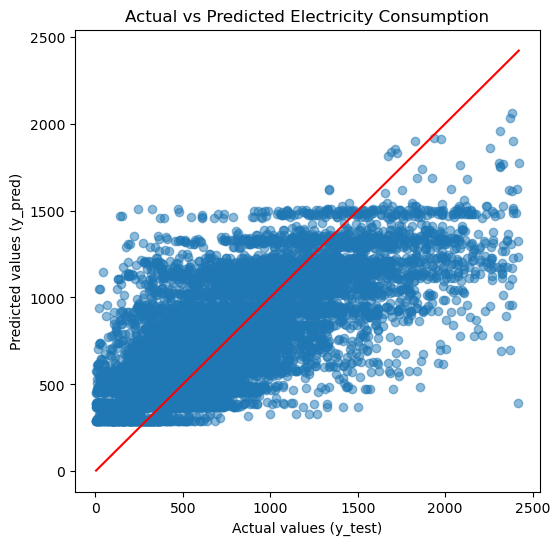

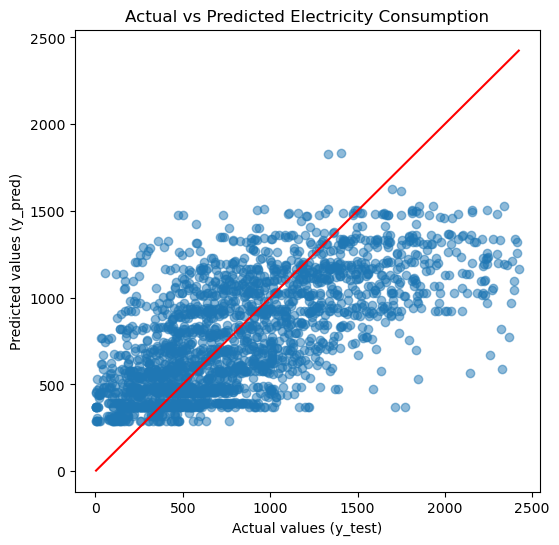

In [210]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# 1. Create model
rf = RandomForestRegressor(
    n_estimators=100,
    max_depth=5,
    random_state=42
)


# 2. Train model
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

# 3. Predictions
compute_metrics(rf, X_train, y_train)
compute_metrics(rf, X_test, y_test)
plot_predictions(rf, X_train, y_train)
plot_predictions(rf, X_test, y_test)

## Polynomial Regression Code


In [211]:
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import Ridge

In [212]:
poly = PolynomialFeatures(degree=2) 
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)
model_poly = Ridge(alpha=0.1)
model_poly.fit(X_train_poly, y_train)
y_pred_poly = model_poly.predict(X_test_poly)
mae = mean_absolute_error(y_test, y_pred_poly)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_poly))
r2 = r2_score(y_test, y_pred_poly)
print("Polynomial Ridge Results:") 
print("MAE:", mae) 
print("RMSE:", rmse) 
print("R²:", r2)


Polynomial Ridge Results:
MAE: 297.4935099015343
RMSE: 389.8190550108584
R²: 0.45108041505055374


## Classification with Logistic Regression

We convert consumption into:

**low** (0)
**medium** (1)
**high** (2)

In [214]:
from sklearn.linear_model import LogisticRegression
import pandas as pd

# splits data into 3 equal groups
y_class = pd.qcut(y, q=3, labels=[0, 1, 2])
X_train, X_test, y_train, y_test = train_test_split(
    X, y_class, test_size=0.2, random_state=42
)

# Train Logistic Regression
log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train, y_train)

y_pred = log_model.predict(X_test)

from sklearn.metrics import accuracy_score, precision_score, recall_score

print("Logistic Regression Results:")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred, average='weighted'))
print("Recall:", recall_score(y_test, y_pred, average='weighted'))

Logistic Regression Results:
Accuracy: 0.6117751217352811
Precision: 0.5957581881737801
Recall: 0.6117751217352811


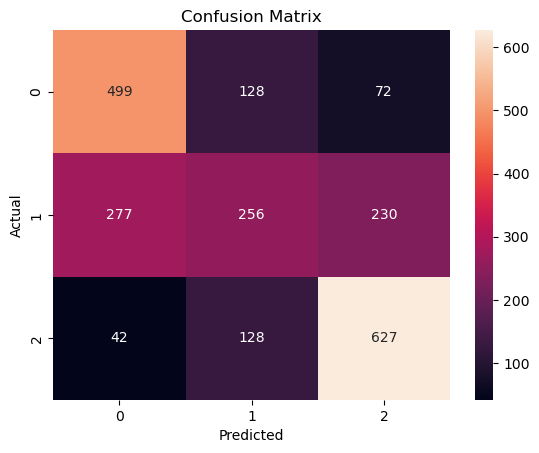

In [217]:
# Confusion Matrix
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [218]:
cm = confusion_matrix(y_test, y_pred)
print(cm)

[[499 128  72]
 [277 256 230]
 [ 42 128 627]]


The model performs well on low and high consumption households, but struggles with the medium class. This indicates that energy consumption behaves as a continuous variable rather than discrete categories, making class separation challenging

Accuracy: 0.7799911465250111
Precision: 0.7845766974015088
Recall: 0.7959183673469388


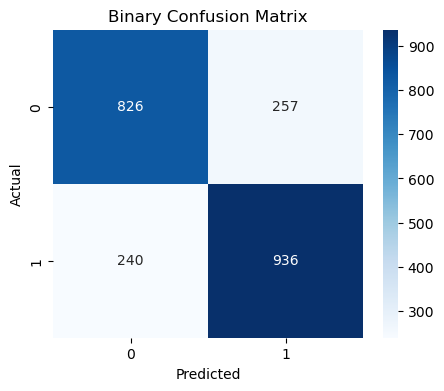